**Seaborn Intro**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

#Data Loading
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

**Install and Import seaborn**

In [2]:
import seaborn as sns

In [11]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_da_us = df_da_us.dropna(subset=['salary_year_avg'])
df_da_us = df_da_us.explode('job_skills')
df_da_us_grouped = df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_da_top_pay = df_da_us_grouped.sort_values(by='median', ascending=False).head(10)
df_da_skills = df_da_us_grouped.sort_values(by='count', ascending=False).head(10)


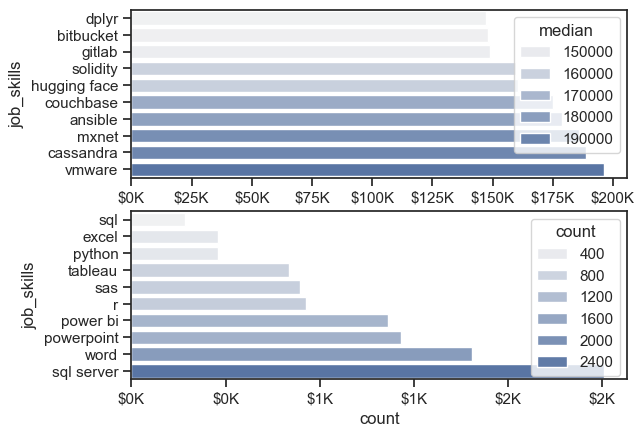

In [26]:
fig, ax = plt.subplots(2, 1)
sns.set_theme(style="ticks")
sns.barplot(df_da_top_pay[::-1].reset_index(), x='median', y=df_da_top_pay.index, hue='median', ax=ax[0], palette='light:b')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

sns.barplot(df_da_skills[::-1].reset_index(), x='count', y=df_da_skills.index, hue='count', ax=ax[1], palette='light:b')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

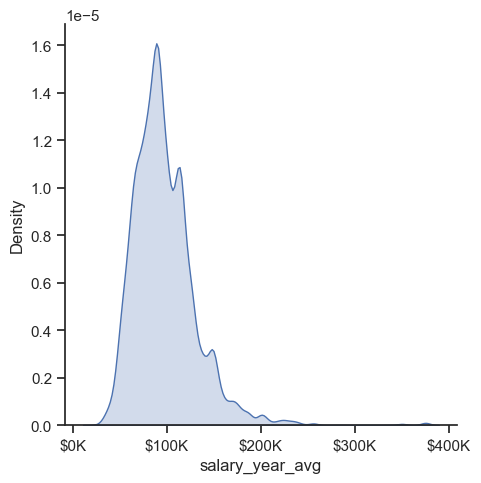

In [ ]:
sns.set_theme(style="ticks")
sns.displot(df_da_us['salary_year_avg'], kind='kde', fill=True)

# plt.gca for getting the current axis of the plot
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))